## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
from transformers import AutoTokenizer

pd.set_option("display.max_colwidth", None)

In [62]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
holdout_test = pd.read_csv("Swahili_News_Test.csv")

print(f"Validate train column names: {holdout_train.columns},\nValidate test column names: {holdout_test.columns}")

Validate train column names: Index(['id', 'content', 'category'], dtype='object'),
Validate test column names: Index(['swahili_id', 'content'], dtype='object')


In [63]:
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv")
swahili_news.head()

,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini China kati ya Juni 19 hadi Juni 26 mwaka huu.Misafara hiyo itatembelea miji ya Beijing Juni 19, Shanghai Juni 21, Nanjig Juni 24 na Changsha Juni 26.Mwenyekiti wa bodi TTB, Jaji Mstaafu Thomas Mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini Dar es Salaam.“Tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka China hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini,” amesema Jaji Mihayo.Novemba 2018 TTB ilifanya ziara kwenye miji ya Beijing, Shanghai, Chengdu, Guangzhou na Hong Kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za Air Tanzania.Ziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini Mei mwaka huu kutembelea vivutio vya utalii.",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao. Alisema baada ya kuingia madarakani, Serikali\niliondoa tozo 80, miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine. Rais Dk. Magufuli, aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa Wilaya ya Kyela katika ziara ya kikazi ya siku 10 mkoani\nMbeya. Alisema, sheria ya ufutaji wa tozo hizo\nzilipitishwa na Bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba Mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi. Alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia. “Wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato, narudia kwa viongozi wote, wakurugenzi,\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja,”alisema. Hata hivyo, alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80.",kitaifa
2,SW29725,"Mwandishi Wetu -Singida BENKI ya NMB imetoa msaada wa vifaa mbalimbali vyenye thamani ya zaidi ya Sh milioni 200 katika wilaya kadhaa nchini. Misaada iliyotolewa na benki hiyo inayoongoza kwa kutengeneza faida kati ya benki zote zinazofanya biashara humu nchini ndani ya miezi mitano mwaka huu, inahusisha vifaa vya ujenzi, madawati na vifaa vingine vinavyowezesha ukamilishaji wa miradi ya afya,elimu na usalama wa raia. Benki ya NMB imeshatoa msaada wa vifaa vyenye thamani ya zaidi ya Sh milioni 200 kwa mikoa ya Kanda ya Kati. Akifafanua kuhusu misaada hiyo wakati akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule katika Halmashauri ya Wilaya ya Iramba mkoani ingida, Meneja wa Kanda ya Kati wa NMB, Nsolo Mlozi, alibainisha kuwa misaada hiyo ya zaidi ya Sh milioni 200 iliyotolewa imelenga sekta ya elimu, afya na majanga kwa mikoa mitatu ya Kanda ya kati. Akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule za Halmashauri ya Wilaya ya Iramba, MkoaniSingida, katika shule ya Sekondari ya New Kiomboi, Mlozi alisema fedha hizo zilizotolewa na NMB zimetumika kununua madawati, viti vya shule za sekondari,vitanda na vifaa tiba kwenye sekta ya afya. Aidha, alisema lengo la misaada hiyo ni kuunga mkono juhudi za serikali kuwahudumia wananchi kwenye sekta mbalimbali. Pia alisema misaada hiyo imekabidhiwa kwa baadhi ya shule, zahanati, hospitali katika mikoa ya Singida, Dodoma na Manyara. Pia NMB walikabidhi madawati 250 na vitanda 80 vyenye thamani ya zaidi ya Sh milioni 29.5 kwa baadhi ya shule za Wilaya ya Iramba mkoani humo. Katika hatua nyingine, Benki hiyo imevipatia kituo cha Polisi Wilaya ya Kilosa mkoani Morogoro pamoja na shule ya msingi Msowelo mabati 160 yenye thamani ya Sh5 milioni kwa ajili ya kuezekea maboma. NMB iliamua kutoa msaada huo ikiwa ni mpango wa kuzipunguza baadhi ya changamoto kwa taasisi za serikali hapa nchini, Meneja 

In [64]:
holdout_train["content"] = holdout_train["content"].apply(lambda x: str(x.lower().rstrip().lstrip()))
swahili_news["content"] = swahili_news["content"].apply(lambda x: str(x.lower().rstrip().lstrip()))
swahili_news["category"] = swahili_news["category"].apply(lambda x: str(x.lower().rstrip().lstrip()))
holdout_train["category"] = holdout_train["category"].apply(lambda x: str(x.lower().rstrip().lstrip()))

In [65]:
print(
    f"Training set has {swahili_news.shape[0]} rows while validation/developer set has {holdout_train.shape[0]} rows."
    )

Training set has 23268 rows while validation/developer set has 5151 rows.


In [66]:
print(
    f"Categories in training but missing in validation: {set(swahili_news["category"].str.lower().unique()) - set(holdout_train["category"].str.lower().unique())}"
    )

Categories in training but missing in validation: {'afya', 'uchumi'}


In [67]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].str.lower().unique()) - set(swahili_news["category"].str.lower().unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [68]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].unique()) - set(swahili_news["category"].unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [69]:
print(
    f"Categories is training data: {swahili_news["category"].str.lower().unique()}.\nCategories in validation set: {holdout_train["category"].str.lower().unique()}"
    )

Categories is training data: ['uchumi' 'kitaifa' 'michezo' 'kimataifa' 'burudani' 'afya'].
Categories in validation set: ['kitaifa' 'biashara' 'michezo' 'kimataifa' 'burudani']


In [70]:
set(
    holdout_train["category"].str.lower().unique()
    ) & set(
        swahili_news["category"].str.lower().unique()
        )

{'burudani', 'kimataifa', 'kitaifa', 'michezo'}

In [71]:
swahili_news["category"].value_counts()

category
kitaifa      10242
michezo       6004
burudani      2229
uchumi        2028
kimataifa     1906
afya           859
Name: count, dtype: int64

In [72]:
holdout_train["category"].value_counts()

category
kitaifa      2000
michezo      1720
biashara     1360
kimataifa      54
burudani       17
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

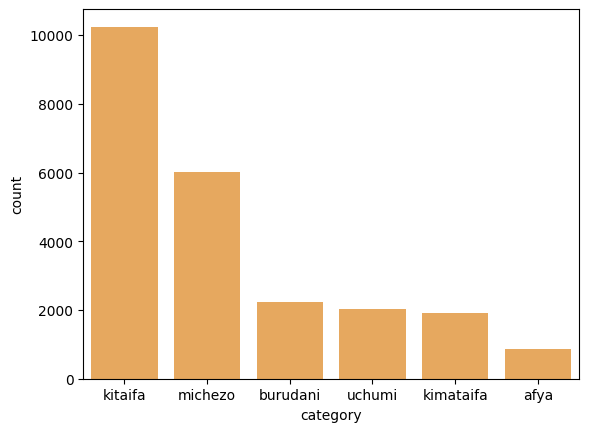

In [73]:
sns.countplot(
    x="category",
    data=swahili_news,
    color="#fdaa48",
    order=swahili_news["category"].value_counts().index
    )

<Axes: xlabel='category', ylabel='count'>

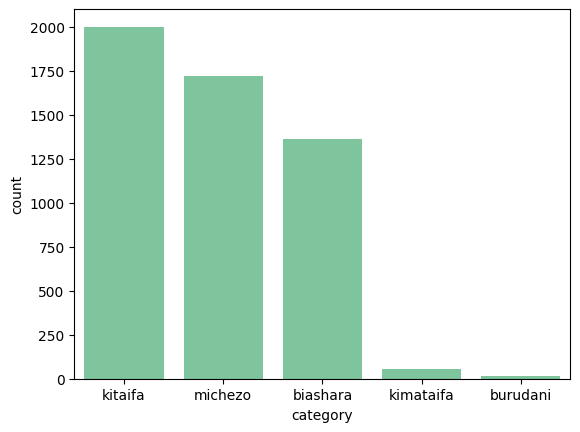

In [74]:
sns.countplot(
    x="category",
    data=holdout_train,
    color="#72d09c",
    order=holdout_train["category"].value_counts().index
    )

In [75]:
holdout_train[holdout_train["content"] == str(swahili_news.loc[1, "content"].lower().rstrip().lstrip())]

,id,content,category


In [76]:
swahili_news.loc[23258, "content"].lower().rstrip().lstrip()

'na ramadhan libenanga-morogoro \nwafugaji wilayani mvomero mkoa wa morogoro, wamesema wamekuwa wakitumia fedha nyingi kununua mihtasari ya vikao vya vijiji ili kuzionyesha mamlaka mbalimbali jinsi walivyoruhusiwa kumiliki ardhi waliyonayo.\nhayo yalielezwa jana na mchungaji joseph sepuke, alipokuwa akizungumza kwenye mkutano wa hadhara katika kijiji cha kibaoni wilayani mvomero. \n“wamasai wanapata mihtasari ya kijiji kwa gharama kubwa na viongozi hawa hawa wa vijiji ndio wanaowauzia hii mihtasari ili waweze kumilikishwa maeneo. \n“kwa hiyo, tunaomba gharama za mihtasari hiyo zipunguzwe ili tuweze kuzipata kwa urahisi zaidi,” alisema sepuke.\nawali, akizungumza katika mkutano huo, mjumbe wa serikali ya kijiji cha kibaoni, fabian beatus, alisema kijiji chao kimegundua kuna baadhi ya wananchi walioghushi mihtasari ya vijiji na kufanikiwa kupata ardhi. \n“kuna watu wameghushi mihtasari kwa sababu sharti kuu linalomwezesha mwananchi kumiliki ardhi ni kuwa na muhtasari unaoonyesha vikao ha

In [77]:
set(holdout_train["id"].unique().tolist()) - set(swahili_news["id"].unique().tolist())

{'SW1359',
 'SW5139',
 'SW5198',
 'SW760',
 'SW350',
 'SW1923',
 'SW3162',
 'SW3069',
 'SW1093',
 'SW3384',
 'SW739',
 'SW6224',
 'SW1616',
 'SW217',
 'SW2395',
 'SW5418',
 'SW2723',
 'SW5478',
 'SW4192',
 'SW2671',
 'SW5925',
 'SW3298',
 'SW4867',
 'SW3039',
 'SW1699',
 'SW976',
 'SW4926',
 'SW430',
 'SW3916',
 'SW3978',
 'SW4406',
 'SW1320',
 'SW4633',
 'SW3242',
 'SW1931',
 'SW6415',
 'SW4704',
 'SW5031',
 'SW2471',
 'SW842',
 'SW2532',
 'SW3573',
 'SW3250',
 'SW1794',
 'SW4197',
 'SW1195',
 'SW3127',
 'SW4000',
 'SW6173',
 'SW5567',
 'SW3089',
 'SW3360',
 'SW6353',
 'SW6376',
 'SW5943',
 'SW997',
 'SW4479',
 'SW5469',
 'SW2354',
 'SW5979',
 'SW914',
 'SW5329',
 'SW6379',
 'SW1307',
 'SW424',
 'SW4885',
 'SW1772',
 'SW352',
 'SW5339',
 'SW2253',
 'SW5358',
 'SW4088',
 'SW3125',
 'SW6140',
 'SW5814',
 'SW412',
 'SW256',
 'SW6226',
 'SW4941',
 'SW2312',
 'SW741',
 'SW2715',
 'SW5713',
 'SW1029',
 'SW4329',
 'SW2130',
 'SW381',
 'SW4691',
 'SW5009',
 'SW1232',
 'SW5484',
 'SW3126',
 'S

In [78]:
set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())

{'SW1960',
 'SW2252',
 'SW734',
 'SW4233',
 'SW2010',
 'SW2753',
 'SW2505',
 'SW5089',
 'SW4681',
 'SW2788',
 'SW452',
 'SW1822',
 'SW725',
 'SW1392',
 'SW4168',
 'SW67',
 'SW4029',
 'SW665',
 'SW366',
 'SW1892',
 'SW265',
 'SW4645',
 'SW1116',
 'SW5869',
 'SW5459',
 'SW1605',
 'SW984',
 'SW2653',
 'SW3283',
 'SW1712',
 'SW4775',
 'SW165',
 'SW36',
 'SW34',
 'SW230',
 'SW3618',
 'SW6071',
 'SW2969',
 'SW3482',
 'SW2449',
 'SW5435',
 'SW2862',
 'SW1713',
 'SW227',
 'SW5682',
 'SW1588',
 'SW398',
 'SW6241',
 'SW3239',
 'SW3949',
 'SW4801',
 'SW5845',
 'SW2018',
 'SW1810',
 'SW3112',
 'SW3541',
 'SW789',
 'SW5898',
 'SW1210',
 'SW2907',
 'SW1920',
 'SW4264',
 'SW4036',
 'SW807',
 'SW3429',
 'SW3038',
 'SW5153',
 'SW5622',
 'SW4149',
 'SW6240',
 'SW5395',
 'SW3034',
 'SW6393',
 'SW3553',
 'SW902',
 'SW3324',
 'SW4231',
 'SW5803',
 'SW6057',
 'SW5481',
 'SW709',
 'SW2195',
 'SW236',
 'SW4547',
 'SW5983',
 'SW4864',
 'SW4492',
 'SW4858',
 'SW96',
 'SW2270',
 'SW2119',
 'SW5623',
 'SW2198',
 

In [79]:
swahili_news[swahili_news["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

id  \
0      SW4670   
7      SW1223   
20      SW548   
24      SW271   
32     SW2327   
...       ...   
23257  SW3133   
23258  SW6098   
23261  SW5272   
23262   SW897   
23264  SW4038   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [80]:
holdout_train[holdout_train["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

id  \
0        SW0   
2       SW10   
3      SW100   
4     SW1000   
5     SW1002   
...      ...   
5145   SW992   
5146   SW993   
5147   SW994   
5148   SW996   
5150   SW999   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [81]:
# merge the datasets
merged_swahili_news = pd.concat([swahili_news, holdout_train])

In [82]:
swahili_news.shape[0] + holdout_train.shape[0]

28419

In [83]:
swahili_news[swahili_news["category"] == "kitaifa"].head()

id  \
1  SW30826   
4  SW12560   
5  SW30734   
6  SW28096   
9   SW9193   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [84]:
holdout_train[holdout_train["category"] == "kitaifa"].head()

id  \
0      SW0   
2     SW10   
4   SW1000   
7   SW1004   
10  SW1009   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [85]:
[news for news in swahili_news["content"].tolist() if "serikali imesema haitakuwa" in news]

['serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia seri

In [86]:
merged_swahili_news[merged_swahili_news["content"].duplicated()]

id  \
40    SW29020   
50    SW13033   
142   SW29598   
211   SW24604   
262   SW23250   
...       ...   
5146    SW993   
5147    SW994   
5148    SW996   
5149    SW997   
5150    SW999   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [87]:
merged_swahili_news[~merged_swahili_news["content"].duplicated()]

,id,content,category
0,SW4670,"bodi ya utalii tanzania (ttb) imesema, itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huu.misafara hiyo itatembelea miji ya beijing juni 19, shanghai juni 21, nanjig juni 24 na changsha juni 26.mwenyekiti wa bodi ttb, jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam.“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini,” amesema jaji mihayo.novemba 2018 ttb ilifanya ziara kwenye miji ya beijing, shanghai, chengdu, guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzania.ziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii.",uchumi
1,SW30826,"pendo fundisha-mbeya rais dk. john magufuri, ametangaza kuwafukuza\nkazi wakurugenzi wote wa halmashauri ambao watabainika kukiuka sheria ya\nufutaji wa tozo za ushuru wa mazao. alisema baada ya kuingia madarakani, serikali\niliondoa tozo 80, miongoni mwa hizo tozo ushuru wakulima ambao walikuwa\nwakilipa mazao kutoka halmashauri moja kwenda nyingine. rais dk. magufuli, aliyasema hayo juzi alipokuwa\nakiwahutubia wakazi wa wilaya ya kyela katika ziara ya kikazi ya siku 10 mkoani\nmbeya. alisema, sheria ya ufutaji wa tozo hizo\nzilipitishwa na bunge hivyo hakuna mtu yoyote wa kuitengua na kwamba mkurugenzi\natakaye itengua atakuwa umevunja sheria na anawajibu wa kufukuzwa kazi. alisema licha ya kupitishwa kwa sheria hiyo wapo\nbaadhi ya watendaji wameendelea kuwatoza ushuru wananchi kwa kisingizio cha\nkupandisha ukusanyaji wa mapato hilo jambo sitaki kulisikia. “wapo watendaji\nwanasema kufutwa kwa ushuru kunapunguza mapato, narudia kwa viongozi wote, wakurugenzi,\nwatendaji wote wa halmashauri msiwatoze wananchi ushuru wa mzigo wowote usio\nzidi tani moja,”alisema. hata hivyo, alitoa wito kwa watendaji kuzingatia\nsheria ya kuwalinda wakulima na ndio maana serikali iliziondoa tozo 80.",kitaifa
2,SW29725,"mwandishi wetu -singida benki ya nmb imetoa msaada wa vifaa mbalimbali vyenye thamani ya zaidi ya sh milioni 200 katika wilaya kadhaa nchini. misaada iliyotolewa na benki hiyo inayoongoza kwa kutengeneza faida kati ya benki zote zinazofanya biashara humu nchini ndani ya miezi mitano mwaka huu, inahusisha vifaa vya ujenzi, madawati na vifaa vingine vinavyowezesha ukamilishaji wa miradi ya afya,elimu na usalama wa raia. benki ya nmb imeshatoa msaada wa vifaa vyenye thamani ya zaidi ya sh milioni 200 kwa mikoa ya kanda ya kati. akifafanua kuhusu misaada hiyo wakati akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule katika halmashauri ya wilaya ya iramba mkoani ingida, meneja wa kanda ya kati wa nmb, nsolo mlozi, alibainisha kuwa misaada hiyo ya zaidi ya sh milioni 200 iliyotolewa imelenga sekta ya elimu, afya na majanga kwa mikoa mitatu ya kanda ya kati. akikabidhi msaada wa madawati na vitanda kwa baadhi ya shule za halmashauri ya wilaya ya iramba, mkoanisingida, katika shule ya sekondari ya new kiomboi, mlozi alisema fedha hizo zilizotolewa na nmb zimetumika kununua madawati, viti vya shule za sekondari,vitanda na vifaa tiba kwenye sekta ya afya. aidha, alisema lengo la misaada hiyo ni kuunga mkono juhudi za serikali kuwahudumia wananchi kwenye sekta mbalimbali. pia alisema misaada hiyo imekabidhiwa kwa baadhi ya shule, zahanati, hospitali katika mikoa ya singida, dodoma na manyara. pia nmb walikabidhi madawati 250 na vitanda 80 vyenye thamani ya zaidi ya sh milioni 29.5 kwa baadhi ya shule za wilaya ya iramba mkoani humo. katika hatua nyingine, benki hiyo imevipatia kituo cha polisi wilaya ya kilosa mkoani morogoro pamoja na shule ya msingi msowelo mabati 160 yenye thamani ya sh5 milioni kwa ajili ya kuezekea maboma. nmb iliamua kutoa msaada huo ikiwa ni mpango wa kuzipunguza baadhi ya changamoto kwa taasisi za serikali hapa nchini, meneja 

In [88]:
4908 + 23511

28419

In [89]:
merged_swahili_news.shape

(28419, 3)

In [90]:
merged_swahili_news["category"].unique()

array(['uchumi', 'kitaifa', 'michezo', 'kimataifa', 'burudani', 'afya',
       'biashara'], dtype=object)

In [91]:
(merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0] / merged_swahili_news.shape[0]) * 100

17.270136176501634

In [92]:
merged_swahili_news[merged_swahili_news["content"].duplicated()].loc[0, "content"]

'serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serik

In [93]:
merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

,id,content,category
5493,SW9596,"serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa.",kitaifa
0,SW0,"serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa.",kitaifa


In [94]:
tokenizer = AutoTokenizer.from_pretrained("Benjamin-png/bert-tokenizer-swahili")

In [95]:
tokenizer.tokenize(merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]["content"])

Token indices sequence length is longer than the specified maximum sequence length for this model (546 > 512). Running this sequence through the model will result in indexing errors


['serikali',
 'imesema',
 'haitakuwa',
 'tayari',
 'kuona',
 'amani',
 'na',
 'utulivu',
 'wa',
 'nchi',
 'ina',
 '##chezewa',
 'huku',
 'ikisisitiza',
 'uwepo',
 'wa',
 'umoja',
 'kati',
 'ya',
 'wananchi',
 'bila',
 'kujali',
 'tofauti',
 'ya',
 'imani',
 ',',
 'kabila',
 'au',
 'itikadi',
 'yoyote',
 '.',
 'hayo',
 'yalisemwa',
 'na',
 'naibu',
 'waziri',
 'wa',
 'mambo',
 'ya',
 'ndani',
 'ya',
 'nchi',
 ',',
 'hamad',
 'yussuf',
 'masauni',
 'wakati',
 'akifungua',
 'semina',
 'ya',
 'siku',
 'mbili',
 'iliyofanyika',
 'jijini',
 'dar',
 'es',
 'salaam',
 'ikiwa',
 '##husisha',
 'viongozi',
 'wa',
 'taasisi',
 'za',
 'kiislamu',
 ',',
 'lengo',
 'ikiwa',
 'ni',
 'kuwakumbusha',
 'kuhubiri',
 'amani',
 'katika',
 'sehemu',
 'zao',
 '.',
 'naibu',
 'waziri',
 'amesema',
 'mwelekeo',
 'na',
 'malengo',
 'ya',
 'serikali',
 'ya',
 'awamu',
 'ya',
 'tano',
 'ni',
 'kukuza',
 'maendeleo',
 'katika',
 'sehemu',
 'mbalimbali',
 'nchini',
 'lengo',
 'ikiwa',
 'kuinua',
 'maisha',
 'ya',
 '

In [96]:
merged_swahili_news["content"] = merged_swahili_news["content"].str.replace(r'[.,]', '', regex=True)

In [97]:
def tokenize(text):
    text = tokenizer.tokenize(text)
    return text

merged_swahili_news["tokenized"] = merged_swahili_news["content"].apply(lambda x: tokenize(x))

In [98]:
merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

,id,content,category,tokenized


In [99]:
merged_swahili_news.loc[5493, "tokenized"]

['serikali',
 'imesema',
 'haitakuwa',
 'tayari',
 'kuona',
 'amani',
 'na',
 'utulivu',
 'wa',
 'nchi',
 'ina',
 '##chezewa',
 'huku',
 'ikisisitiza',
 'uwepo',
 'wa',
 'umoja',
 'kati',
 'ya',
 'wananchi',
 'bila',
 'kujali',
 'tofauti',
 'ya',
 'imani',
 'kabila',
 'au',
 'itikadi',
 'yoyote',
 '##hayo',
 'yalisemwa',
 'na',
 'naibu',
 'waziri',
 'wa',
 'mambo',
 'ya',
 'ndani',
 'ya',
 'nchi',
 'hamad',
 'yussuf',
 'masauni',
 'wakati',
 'akifungua',
 'semina',
 'ya',
 'siku',
 'mbili',
 'iliyofanyika',
 'jijini',
 'dar',
 'es',
 'salaam',
 'ikiwa',
 '##husisha',
 'viongozi',
 'wa',
 'taasisi',
 'za',
 'kiislamu',
 'lengo',
 'ikiwa',
 'ni',
 'kuwakumbusha',
 'kuhubiri',
 'amani',
 'katika',
 'sehemu',
 'zao',
 '##nai',
 '##bu',
 'waziri',
 'amesema',
 'mwelekeo',
 'na',
 'malengo',
 'ya',
 'serikali',
 'ya',
 'awamu',
 'ya',
 'tano',
 'ni',
 'kukuza',
 'maendeleo',
 'katika',
 'sehemu',
 'mbalimbali',
 'nchini',
 'lengo',
 'ikiwa',
 'kuinua',
 'maisha',
 'ya',
 'wananchi',
 'na',
 